In [1]:
import os

TRAIN = '/kaggle/input/datasets/athulyas1206/bharatanatyam-mudras/Bharatanatyam_Mudras'

os.listdir(path=TRAIN)

['Musti', 'Pataka', 'Simhamukha', 'Trisula', 'Sikhara']

We want to use ResNeXt image embeddings for both EDA and classification, so let's add some code to get them for us.

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 110MB/s]


Let's load up all of our data. We only have five classes, and about 400 images per class, so this won't take long.

In [3]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image


THUMBNAIL_SIZE = (32, 32)

def embed(model, filename: str):
    with Image.open(fp=filename, mode='r') as image:
        return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        # our images are pretty big; let's shrink the hover images to thumbnail size
        image.resize(size=THUMBNAIL_SIZE).convert('RGBA').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    time_get = arrow.now()
    input_files = list(iglob(pathname=arg))
    input_files = [item for item in input_files if (item.endswith('.JPG') or item.endswith('.jpg'))]
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'] )
        for index, input_file in enumerate(tqdm.tqdm(input_files))]
    print('encoded {} rows of {}  in {}'.format(len(result), tag, arrow.now() - time_get))
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TRAIN + '/*') if isdir(folder) }
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key.replace('_', ' ')) for key, value in train_dict.items()]))
print('done in {}'.format(arrow.now() - time_start))

100%|██████████| 400/400 [01:10<00:00,  5.64it/s]


encoded 400 rows of Musti  in 0:01:10.963282


100%|██████████| 400/400 [01:07<00:00,  5.91it/s]


encoded 400 rows of Pataka  in 0:01:07.665778


100%|██████████| 400/400 [01:07<00:00,  5.93it/s]


encoded 400 rows of Simhamukha  in 0:01:07.508590


100%|██████████| 400/400 [01:07<00:00,  5.93it/s]


encoded 400 rows of Trisula  in 0:01:07.469055


100%|██████████| 400/400 [01:07<00:00,  5.94it/s]


encoded 400 rows of Sikhara  in 0:01:07.321705
done in 0:05:41.145317


Our classes are balanced.

In [4]:
train_df['tag'].value_counts(normalize=True).to_frame().T

tag,Musti,Pataka,Simhamukha,Trisula,Sikhara
proportion,0.2,0.2,0.2,0.2,0.2


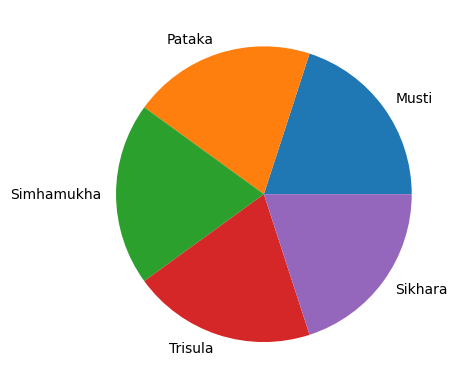

In [5]:
import matplotlib.pyplot as plt

train_df['tag'].value_counts(normalize=False).to_frame().plot.pie(y='count')
plt.ylabel('')
plt.legend().remove()
plt.show()

Let's use TSNE to add x/y coordinates based on our image embeddings.

In [6]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.009s...
[t-SNE] Computed neighbors for 2000 samples in 0.503s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 2.624964
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.917030
[t-SNE] KL divergence after 1000 iterations: 0.255993


Let's plot.

In [7]:
from bokeh.models import ColumnDataSource
from bokeh.models import HoverTool

from bokeh.plotting import figure
from bokeh.plotting import output_notebook
from bokeh.plotting import show
from bokeh.palettes import Turbo256
from bokeh.transform import factor_cmap

output_notebook()

datasource = ColumnDataSource(train_df[['png', 'tag', 'x', 'y']].sample(n=min(len(train_df) - 1, 10000)))
factor_count = max(train_df['tag'].nunique(), 3)
indices = np.linspace(0, len(Turbo256)-1, factor_count, dtype=int)
palette = [Turbo256[index] for index in indices]
mapper = factor_cmap(field_name = 'tag', palette=palette, factors=train_df['tag'].unique().tolist(), start=0, end=factor_count-1, )

plot_figure = figure(title='TSNE projection: hand gestures', width=1000, height=800, tools=('pan, wheel_zoom, reset'))

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@png' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 18px'>@tag</span>
    </div>
</div>
"""))

plot_figure.scatter(x='x', y='y', source=datasource, line_alpha=0.6, fill_alpha=0.6, size=8, color=mapper)
show(plot_figure)

Loading BokehJS ...

We don't have an enormous amount of data; let's make a static plot.

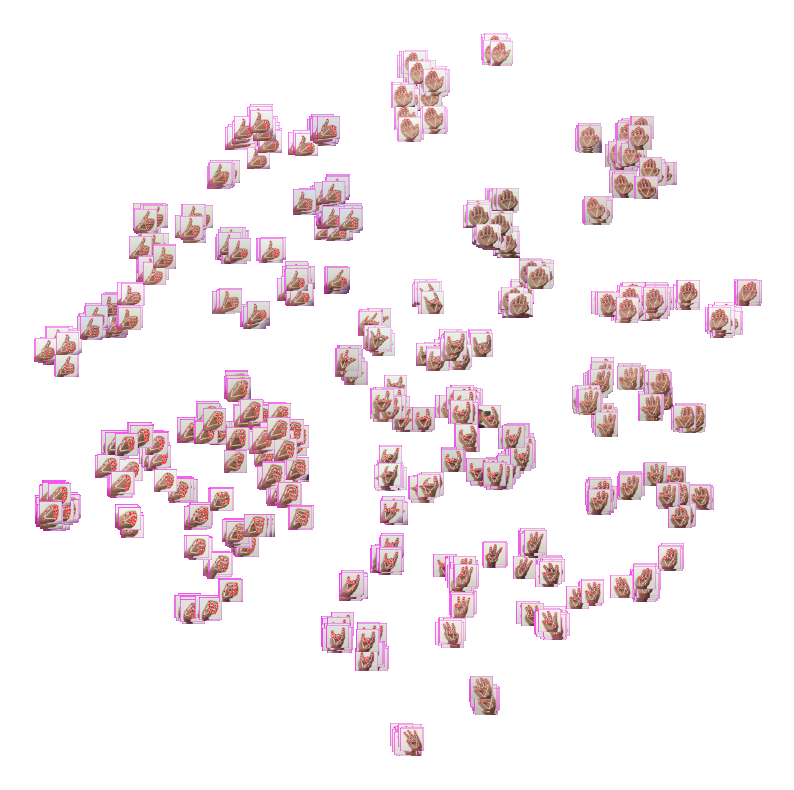

In [8]:
import base64
import io
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from PIL import Image

# we recycled some PNG encoding code above, and we need to postprocess it for using with matplotlib
train_df['PNG'] = train_df['png'].str.replace('^data:image/png;base64,', '', regex=True)

fig, ax = plt.subplots(figsize=(10, 10))

for index, row in train_df.iterrows():
    img_bytes = base64.b64decode(row["PNG"])
    img = Image.open(io.BytesIO(img_bytes))
    imagebox = OffsetImage(img, zoom=0.5)
    ab = AnnotationBbox(imagebox, (row["x"], row["y"]), frameon=False, pad=0)
    ax.add_artist(ab)
ax.scatter(train_df["x"], train_df["y"], alpha=0)
ax.axis('off')
plt.show()

What do we see? We see evidence of data augmentation (the tiny, dense local clusters), but we also see that our classes do not mix. Let's build a model.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_df['value'].apply(pd.Series), train_df['tag'], test_size=0.25, random_state=2026, stratify=train_df['tag'])
logreg = LogisticRegression(max_iter=10000, tol=1e-12).fit(X_train, y_train)
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=y_test, y_pred=logreg.predict(X=X_test))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=y_test, y_pred=logreg.predict(X=X_test))))
print(classification_report(y_true=y_test, y_pred=logreg.predict(X=X_test), zero_division=0.0))

model fit in 383 iterations
accuracy: 1.0000
f1: 1.0000
              precision    recall  f1-score   support

       Musti       1.00      1.00      1.00       100
      Pataka       1.00      1.00      1.00       100
     Sikhara       1.00      1.00      1.00       100
  Simhamukha       1.00      1.00      1.00       100
     Trisula       1.00      1.00      1.00       100

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



Not surprisingly our f1 scores are all really high. In fact we have zero misclassifications. Let's look at our model probabilities.

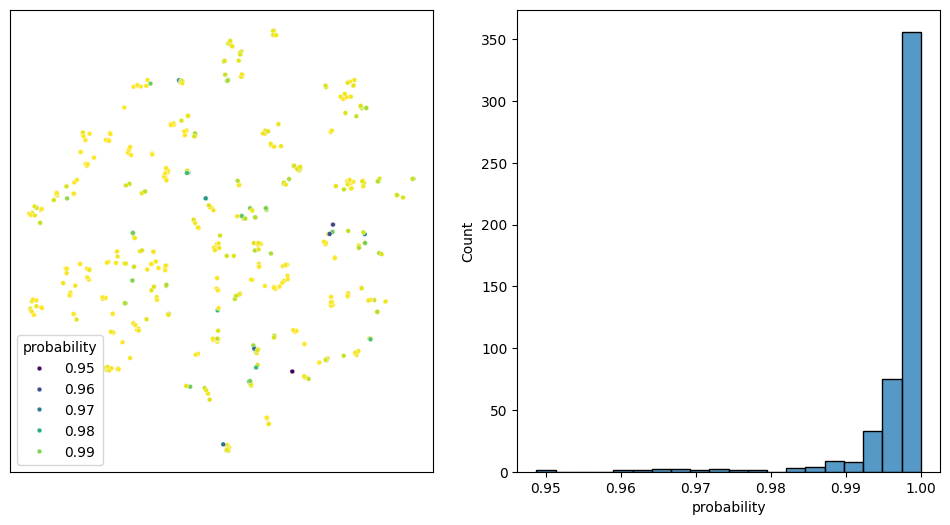

In [10]:
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = train_df.iloc[X_test.index][['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=X_test), axis=1)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', s=12)
ax[0].set(xlabel=None) 
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=20)
fig.show()

All of our model probabilities are really high. Yay.